In [1]:
import numpy as np
import matplotlib.pyplot as plt

import gamex_cascades as gx       # samplers, estimators and the animations live in that file

SEED = 123
rng = np.random.default_rng(SEED)

print("NumPy:", np.__version__)

NumPy: 1.26.4


# GAMEX Practical 4 — A Marked Hawkes Process of Extremes

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**
**Suggested time for this Notebook:** 25 minutes

One extreme event rarely comes alone: a crash is followed by more bad days, there and elsewhere.

This notebook builds, step by step, a process in which **every event is an extreme event** and each event can trigger more. The samplers, estimators and animations are in `gamex_cascades.py`, imported above as `gx`.

## Learning goals

By the end you should be able to:

- identify $\mu$, $\eta$, $\beta$, $\kappa$, $\alpha$, $q$ and the gauge $g$ in the code;
- simulate a Hawkes process from its intensity, and attach marks to it;
- recognise extremes as the points outside the limit set of a scaled cloud;
- build an extreme mark from a von Mises-Fisher angle and a truncated-Gamma radius above $u_q(w)$;
- explain the immigration-birth representation and define a cascade by its genealogy;
- estimate $(\mu, \eta, \beta)$ by EM and the limit set by maximum likelihood;
- extract the cascades of a crypto contagion with EM.

## 1. A Hawkes process

Events arrive on a timeline, and **every event raises the rate of the next**,

$$
\lambda(t) = \mu + \sum_{t_i < t} \eta\, \beta\, e^{-\beta (t - t_i)}.
$$

The baseline $\mu = 0.4$ sets how often activity starts on its own; each event adds a bump of area $\eta = 0.78$ — the mean number of further events it triggers — decaying at rate $\beta = 1.2$, and $\eta < 1$ keeps the process stable.

We simulate by Ogata's thinning: propose the next point at the current rate, then keep it with probability $\lambda(\text{proposal}) / \lambda(\text{now})$.

In [2]:
mu = 0.4      # events that start on their own, per unit of time
eta = 0.78    # children per event on average; everything in this notebook turns on it
beta = 1.2    # how quickly the excitement of one event fades


def simulate_times(T, rng):
    t = []
    s = 0.0
    while s < T:
        lam_bar = mu + eta * beta * np.sum(np.exp(-beta * (s - np.array(t))))   # an upper bound: lambda only decays between events
        s += rng.exponential(1.0 / lam_bar)                                     # propose a point
        lam_s = mu + eta * beta * np.sum(np.exp(-beta * (s - np.array(t))))
        if s < T and rng.random() < lam_s / lam_bar:   # keep it with that ratio: this is thinning
            t.append(s)
    return np.array(t)


t100 = simulate_times(100.0, np.random.default_rng(11))
print("Events on (0, 100):", len(t100))

Events on (0, 100): 168


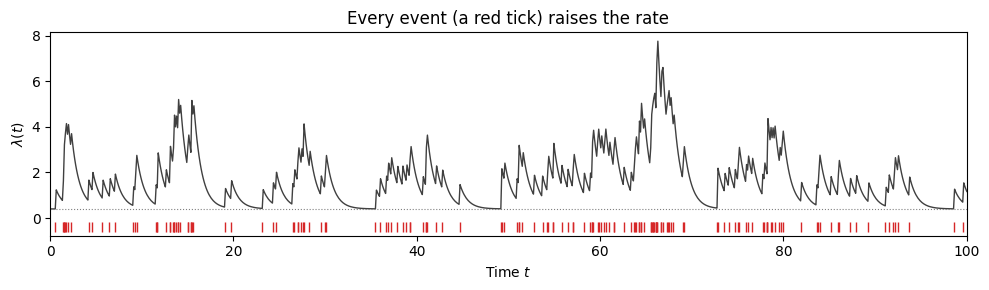

In [3]:
t_grid = np.linspace(0.0, 100.0, 900)
lag = t_grid[:, None] - t100[None, :]
# the rate the process felt at each point of the grid
lam = mu + eta * beta * np.sum(np.exp(-beta * np.clip(lag, 0.0, None)) * (lag > 0), axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_grid, lam, color="0.25", lw=1.0)
ax.axhline(mu, color="0.5", ls=":", lw=0.8)
ax.plot(t100, np.full(len(t100), -0.05 * lam.max()), "|", color="C3", ms=7)
ax.set_xlim(0, 100)
ax.set_ylim(-0.1 * lam.max(), 1.05 * lam.max())
ax.set_xlabel(r"Time $t$")
ax.set_ylabel(r"$\lambda(t)$")
ax.set_title("Every event (a red tick) raises the rate")
plt.tight_layout()
plt.show()

## 2. A marked Hawkes process

A **marked** Hawkes process attaches to each event a mark: the times keep the law of Section 1, and the mark records what the event was — a magnitude, a location, a loss.

The figure attaches an arbitrary positive size to each event of Section 1. The rest of the notebook builds the mark that interests us, **an extreme position in $\mathbb{R}^3$**.

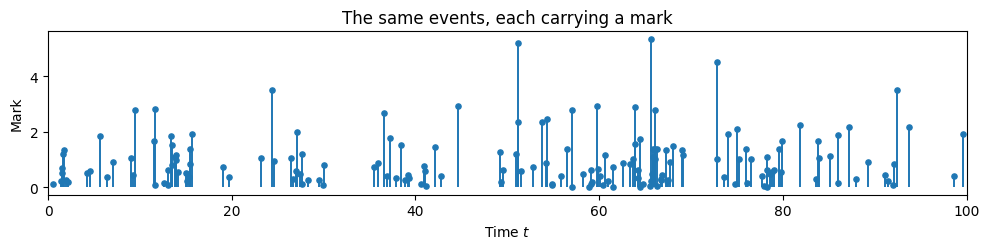

In [4]:
m100 = np.random.default_rng(2).exponential(1.0, size=len(t100))   # any positive number will do
# the mark we actually want arrives in Section 5

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.vlines(t100, 0.0, m100, colors="C0", lw=1.4)
ax.scatter(t100, m100, s=14, color="C0", zorder=3)
ax.set_xlim(0, 100)
ax.set_xlabel(r"Time $t$")
ax.set_ylabel("Mark")
ax.set_title("The same events, each carrying a mark")
plt.tight_layout()
plt.show()

## 3. Three series, one heavy-tailed law

What should an *extreme* mark look like? We take a toy sample of $60{,}000$ days $X_t \in \mathbb{R}^3$ from a heavy-tailed law; Section 5 defines the generator below.

Multivariate extremes are studied on **standard Laplace margins**, reached on real data by ranking each series and applying

$$
E = \begin{cases} \log(2U), & U < 1/2, \\ -\log\{2(1 - U)\}, & U \ge 1/2, \end{cases}
\qquad
U = \hat F(X)
$$

(Practical 5 does exactly this to three stock indices). The toy is simulated on that scale directly, reaching further on the positive side.

In [5]:
alpha = 3.0
p = 1.6                                # roundness of the body; p = 2 would be an ellipsoid
b_pos = np.array([1.0, 0.85, 0.7])     # how far it reaches on the positive side of each axis
b_neg = np.array([0.55, 0.5, 0.45])    # losses reach less far here than gains


def g(x):
    return gx.lp_gauge(x, p, b_pos, b_neg)   # small where the law reaches far

In [6]:
def sample_underlying(n, rng):
    W = rng.standard_normal((n, 3))
    W /= np.linalg.norm(W, axis=1, keepdims=True)          # a uniform direction
    return (rng.gamma(alpha, size=n) / g(W))[:, None] * W  # a radius with tail rate g


X_days = sample_underlying(60_000, np.random.default_rng(77))   # enough days to see a shape
print("Days:", len(X_days))

Days: 60000


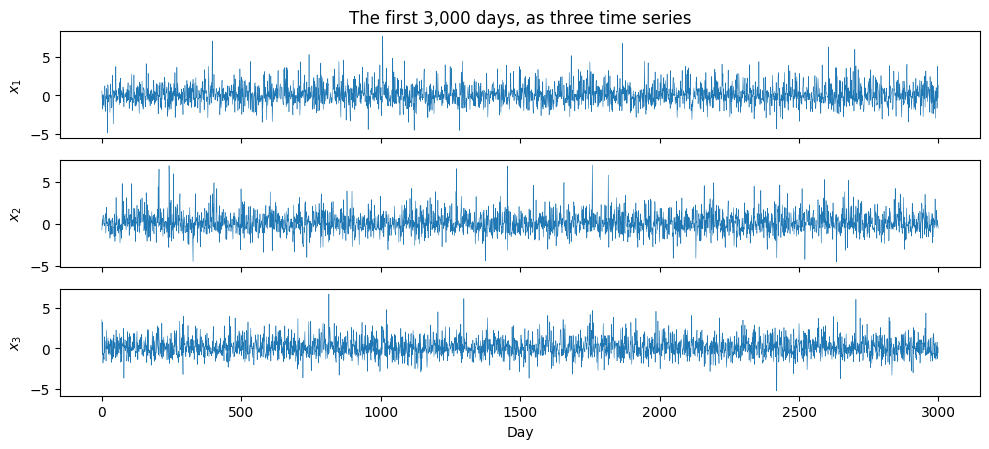

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4.6), sharex=True)
for j, (ax, label) in enumerate(zip(axes, (r"$x_1$", r"$x_2$", r"$x_3$"))):
    ax.plot(X_days[:3000, j], lw=0.4)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Day")
axes[0].set_title("The first 3,000 days, as three time series")
plt.tight_layout()
plt.show()

The same days as a cloud in space: the spread is not the same in every direction.

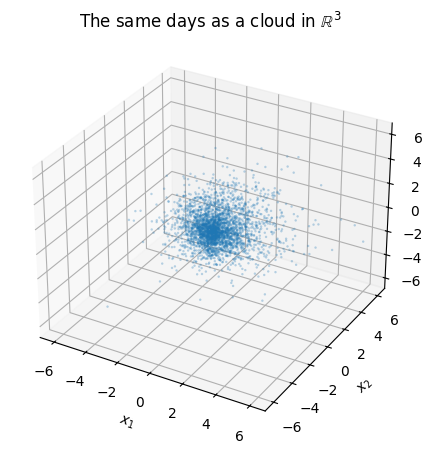

In [8]:
sub = X_days[:3000]
lim = np.quantile(np.abs(sub).max(axis=1), 0.999)

fig = plt.figure(figsize=(6, 5.2))
ax = fig.add_subplot(projection="3d")
ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=3, alpha=0.3, color="C0", linewidths=0)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_zlabel(r"$x_3$")
ax.set_title(r"The same days as a cloud in $\mathbb{R}^3$")
plt.show()

## 4. Extremes live outside the limit set

Shrink the growing cloud by $\log(n/2)$ and it settles into a fixed body, the **limit set** $G$: Laplace-type tails make the largest of $n$ draws grow like $\log n$, and each tail holds half the sample.

**The extremes are the points that fall outside $G$** after the shrinking, drawn in red. The animation grows $n$: the cloud fills the grey body, and at every $n$ a few days lie outside it, along the directions where the law reaches furthest.

In [9]:
n_values = np.unique(np.geomspace(500, 50_000, 12).astype(int))   # the sample sizes we walk through
gx.animate_limit_set(X_days, g, n_values)

## 5. Simulating extremes: the gauge, an angle and a radius

The grey body has an equation. With the **gauge**

$$
g(x) = \Big( \sum_{j=1}^{3} \big( x_j^{+} / b_j^{+} + x_j^{-} / b_j^{-} \big)^{p} \Big)^{1/p},
$$

the limit set is $G = \{x : g(x) \le 1\}$ — small $g(w)$ means far reach in direction $w$, and the generator of Section 3 was drawing radii at rate $g$ all along.

For modelling we split an extreme into a radius and an angle, $X = R\,W$ with $\|W\| = 1$, and give each part its law,

$$
W \mid W_{\mathrm{parent}} = w \;\sim\; \mathrm{vMF}(w, \kappa),
\qquad
R \mid W = w \;\sim\; \mathrm{truncGamma}\{\alpha,\, g(w)\} \ \text{above} \ u_q(w).
$$

The angle imitates the direction of the event that triggered it. The radius follows the truncated-Gamma radial model of geometric extremes, which **builds in extremeness**: $u_q(w)$ is the $q$-quantile of the untruncated $\mathrm{Gamma}\{\alpha, g(w)\}$, so $u_q(w) = C_q / g(w)$ with $C_q$ the $q$-quantile of $\mathrm{Gamma}(\alpha, 1)$.

The surface $\{u_q(w)\, w\}$ is the limit set scaled by $C_q \approx 5.3$, so here "extreme" is fixed by the level $q$ rather than by the sample size.

A `gx.Process` collects the seven ingredients — the three rates, the concentration, the shape, the level and the gauge — plus the law of the events that start a family.

> **Source note.** The truncated-Gamma radial model above the angle-dependent quantile is Wadsworth and Campbell (2024); the limit-set convergence of Section 4 is Nolde and Wadsworth (2022).

In [10]:
kappa = 15.0   # how closely a child copies its parent's direction (about 18 degrees)
q = 0.90       # the level that decides what counts as extreme

# the whole process in one object: three rates, two mark laws, one geometry
truth = gx.Process(mu=mu, eta=eta, beta=beta, kappa=kappa, alpha=alpha, q=q,
                   gauge=g, immigrants=gx.vertex_directions())

print("C_q =", round(truth.C_q, 3), "| u_q(+e_1) =", f"{truth.u_q(np.eye(3)[:1])[0]:.2f}")

C_q = 5.322 | u_q(+e_1) = 5.32


In [11]:
W_check = gx.sample_vmf(np.tile(np.eye(3)[0], (20_000, 1)), truth.kappa, np.random.default_rng(1))
R_check = truth.sample_radii(W_check, np.random.default_rng(2))   # sizes above their own quantile
angle = np.degrees(np.arccos(W_check @ np.eye(3)[0]))

print("Mean angle to the parent:", f"{angle.mean():.1f} deg",
      "| 90% of children within:", f"{np.percentile(angle, 90):.1f} deg")
print("Smallest R - u_q(W) over 20,000 draws:", f"{np.min(R_check - truth.u_q(W_check)):.2e}", "(never negative)")

Mean angle to the parent: 18.7 deg | 90% of children within: 32.3 deg
Smallest R - u_q(W) over 20,000 draws: 8.35e-05 (never negative)


The two surfaces below have the same shape; only the ticks differ, by the factor $C_q$.

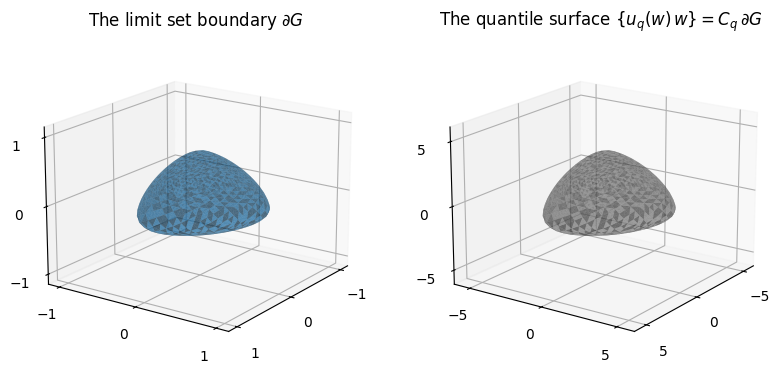

In [12]:
fig = plt.figure(figsize=(9.6, 4.4))
for k, (gauge, lim, ticks, title) in enumerate((
        (g, 1.15, [-1, 0, 1], r"The limit set boundary $\partial G$"),
        (gx.surface_of(truth.u_q), 1.15 * truth.C_q, [-5, 0, 5],
         r"The quantile surface $\{u_q(w)\,w\} = C_q\,\partial G$"))):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    gx.star_surface(ax, gauge, colour="C0" if k == 0 else "0.55", alpha=0.5, n=1400)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
    ax.view_init(elev=18, azim=35)
    ax.set_title(title)
plt.show()

### YOUR TURN 1 — What changes when $q = 0.99$?
---

Try `strict = gx.Process(mu=mu, eta=eta, beta=beta, kappa=kappa, alpha=alpha, q=0.99, gauge=g, immigrants=gx.vertex_directions())` and print its `C_q` and `u_q(+e_1)`.

What happens to the quantile surface, and to the smallest sizes the process can produce?

## 6. The extreme Hawkes process

The marks of our Hawkes process are $(R, W)$ with $R$ already above its own quantile, so **every event is an extreme event**.

Families must start somewhere, so immigrant events get a starting law of their own: `gx.vertex_directions` points them near one of the three axes, mostly on the positive side.

In [13]:
T_TRAIN = 6000.0
# builds the process family by family and writes down every parent
events = truth.simulate(T_TRAIN, np.random.default_rng(SEED))

print("Events on (0, 6000):", len(events))
events.head(3)

Events on (0, 6000): 11239


,t,r,w1,w2,w3,cascade,gen,event,parent,x1,x2,x3
0,1.118279,2.876444,-0.069546,0.128727,-0.989238,0,0,1,0,-0.200046,0.370275,-2.845489
1,2.798516,4.224814,-0.259426,0.965595,-0.017985,1,0,2,0,-1.096028,4.079461,-0.075983
2,3.873106,2.924678,0.023068,0.318833,-0.947530,0,1,3,1,0.067467,0.932484,-2.771220


## 7. What the process looks like

The animation runs sixty time units forward. On the left the intensity climbs at every extreme event and decays between them; on the right the marks appear in space, always outside the quantile surface.

Consecutive extremes land close together, because a child's direction is vMF about its parent's. Colour runs with time.

In [14]:
# the process as data: a timeline and a cloud of marks, no colours
gx.animate_process(truth, events, T=60.0, surface=gx.surface_of(truth.u_q))

## 8. Can we speak of cascades yet?

**Not yet** — nothing in Sections 6 and 7 is labelled by who triggered whom. But the simulator knows, because it builds the process by immigration and birth:

1. place immigrants on $(0, T)$ at rate $\mu$;
2. give each event $\mathrm{Poisson}(\eta)$ children at $\mathrm{Exp}(\beta)$ delays, with vMF directions and truncGamma sizes;
3. repeat on the children until the family dies out;
4. record every parent.

The recorded parenthood is the **genealogy**, and one immigrant together with all its descendants is a **cascade** — a family, not a time window. Its mean size is $1 + \eta + \eta^2 + \cdots = 1/(1-\eta) = 4.55$, which the check verifies.

The animation runs the same fifty time units with the genealogy drawn: each new event joins its parent, one colour per family.

In [15]:
# the same window, now with the parent of each event drawn in
gx.animate_genealogy(events, T=50.0)

In [16]:
sizes = events.groupby("cascade").size()
print("Cascades:", len(sizes), "| Largest:", int(sizes.max()))
print("Mean cascade size:", f"{sizes.mean():.3f}",
      "+-", f"{sizes.std(ddof=1) / np.sqrt(len(sizes)):.3f}",
      "| Theory 1/(1 - eta):", f"{1.0 / (1.0 - eta):.3f}")

Cascades: 2426 | Largest: 93
Mean cascade size: 4.633 +- 0.168 | Theory 1/(1 - eta): 4.545


### YOUR TURN 2 — What happens when $\eta = 0.95$?
---

Try `hot = gx.Process(mu=mu, eta=0.95, beta=beta, kappa=kappa, alpha=alpha, q=q, gauge=g, immigrants=gx.vertex_directions())`, simulate fifty time units from it and animate the genealogy again.

How do the families change? The theory says the mean cascade size is $1/(1-\eta) = 20$.

## 9. Constructing cascades from data: EM

Real data show the times, never the genealogy. The **EM algorithm** reconstructs it in probability: give every event a probability of descending from each earlier event,

$$
\mathbb{P}(\text{parent of } i \text{ is } j) \propto \eta\, \beta\, e^{-\beta (t_i - t_j)},
\qquad
\mathbb{P}(i \text{ is an immigrant}) \propto \mu,
$$

re-estimate $(\mu, \eta, \beta)$ from those probabilities, and repeat; every round provably improves the fit. A sampled or most-probable genealogy then splits the events into cascades.

With eleven thousand events the three rates should come back to within a few percent.

In [17]:
em = gx.fit_em(events["t"], T_TRAIN)   # the times only; the parents are hidden from it

print(f"{'':>6} {'EM':>8} {'truth':>8}")
for name, estimate, true_value in zip(("mu", "eta", "beta"), (em["mu"], em["eta"], em["beta"]), (mu, eta, beta)):
    print(f"{name:>6} {estimate:8.3f} {true_value:8.3f}")
print("Iterations:", len(em["loglik"]),
      "| Decreasing steps of the log-likelihood:", int(np.sum(np.diff(em["loglik"]) < -1e-6)))

             EM    truth
    mu    0.408    0.400
   eta    0.782    0.780
  beta    1.195    1.200
Iterations: 48 | Decreasing steps of the log-likelihood: 0


The rates are recovered; the parenthood stays a table of probabilities. **An inferred parent is a model's guess, never a causal claim.**

## 10. Inferring the limit set: maximum likelihood

The gauge — and with it the limit set — can be estimated from the events alone. Each size contributes its truncated-Gamma log-density, and since a candidate gauge carries its own quantile $u_q(w) = C_q / g(w)$, the truncation term is a constant: **no separate threshold estimation**. Over the $n$ events,

$$
\ell(p, b^{+}, b^{-})
= \sum_{i=1}^{n} \Big\{ \alpha \log g(W_i) + (\alpha - 1) \log R_i - g(W_i)\, R_i \Big\}
- n \log \Gamma(\alpha) - n \log(1 - q),
$$

maximised over the seven parameters of the $\ell^p$ family. The recovered gauge should miss the truth by about **half a percent**, and the two limit sets below should be indistinguishable.

In [18]:
W_train, R_train = gx.directions(events), events["r"].to_numpy()
# seven numbers, recovered from the events alone: no threshold to fit
g_mle, p_hat, b_pos_hat, b_neg_hat = gx.fit_gauge(W_train, R_train, alpha, truth.C_q)

print(f"{'':>6} {'MLE':>22} {'truth':>22}")
print(f"{'p':>6} {p_hat:22.3f} {p:22.3f}")
print(f"{'b+':>6} {str(b_pos_hat.round(3)):>22} {str(b_pos):>22}")
print(f"{'b-':>6} {str(b_neg_hat.round(3)):>22} {str(b_neg):>22}")
grid = gx.sphere_grid(800)   # compare the two gauges over 800 directions
print("Median relative error over the sphere:", f"{np.median(np.abs(g_mle(grid) - g(grid)) / g(grid)):.4f}")

                          MLE                  truth
     p                  1.595                  1.600
    b+    [1.006 0.857 0.706]       [1.   0.85 0.7 ]
    b-    [0.554 0.504 0.454]       [0.55 0.5  0.45]
Median relative error over the sphere: 0.0062


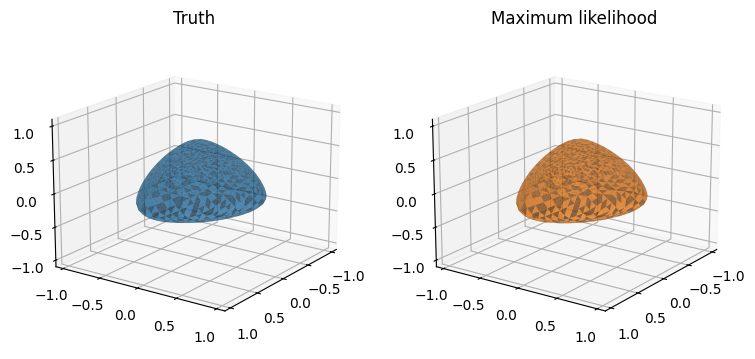

In [19]:
fig = plt.figure(figsize=(9, 4.4))
for k, (name, gauge) in enumerate((("Truth", g), ("Maximum likelihood", g_mle))):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    gx.star_surface(ax, gauge, colour=f"C{k}", alpha=0.55, n=1400)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=18, azim=35)
    ax.set_title(name)
plt.show()

## 11. Activity — Cascades on the GAMEX exchange

The GAMEX exchange now lists three coins: **GamexCoin (GMX)**, **HawkCoin (HWK)** and **TailCoin (TAIL)**. Their communities insist the three have nothing in common; the chart on the right suggests otherwise.

| Three coins | The contagion weekend |
| :---: | :---: |
| <img src="figures/gamex_exchange_coins.png" alt="GMX, HWK, TAIL" width="400"> | <img src="figures/gamex_contagion_banner.png" alt="The contagion weekend" width="560"> |

**A crypto crash is this notebook's extreme Hawkes process with $d = 3$** — component 1 GMX, component 2 HWK, component 3 TAIL; an event is a violent day, its direction says which coins were hit, its size how badly.

You will run the whole notebook on the exchange's own geometry: the cloud of daily returns, the level that separates the extreme days, the gauge fitted to those days, and finally the families, in time and then in the cloud.

Replace every `...` and run.

In [ ]:
# --- Activity, part 1: the cloud and the level q ---
# The exchange's three coins do not reach equally far. Fill in the level that
# decides what counts as an extreme day, then rerun with another one.

b_pos_coins = np.array([0.85, 0.70, 0.60])    # how far GMX, HWK and TAIL reach on a good day
b_neg_coins = np.array([0.55, 0.60, 1.00])    # and on a bad one; TailCoin crashes furthest
g_coins = lambda x: gx.lp_gauge(x, 1.4, b_pos_coins, b_neg_coins)

q_coins = ...                                 # e.g. 0.99

exchange = gx.Process(mu=mu, eta=eta, beta=beta, kappa=kappa, alpha=alpha, q=q_coins,
                      gauge=g_coins, immigrants=gx.vertex_directions())


def sample_days(n, rng):                      # the generator of Section 3, new geometry
    W = rng.standard_normal((n, 3))
    W /= np.linalg.norm(W, axis=1, keepdims=True)
    return (rng.gamma(alpha, size=n) / g_coins(W))[:, None] * W


days = sample_days(30_000, np.random.default_rng(2026))
extreme = g_coins(days) > exchange.C_q        # the definition of an extreme day, in one line
print("Days:", len(days), "| Extreme days:", int(extreme.sum()),
      f"({100 * extreme.mean():.1f}%, and 1 - q is {100 * (1 - q_coins):.1f}%)")

lim = np.quantile(np.abs(days).max(axis=1), 0.999)
fig = plt.figure(figsize=(6.6, 5.6))
ax = fig.add_subplot(projection="3d")
ax.scatter(*days[~extreme].T, s=1.5, alpha=0.07, color="0.3", linewidths=0)
ax.scatter(*days[extreme].T, s=4, alpha=0.45, color="C3", linewidths=0)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_zlabel(r"$x_3$")
ax.set_title("The exchange's daily returns; the extreme days in red")
plt.show()

The red days are the ones outside $C_q \partial G$, and they are the only ones the gauge is fitted to. Below, the seven numbers of the gauge come back from those days alone, and the surface they imply sits next to the exchange's true one.

In [ ]:
# --- Activity, part 2: fit the gauge and recover the limit set ---
# The threshold is tied to the gauge, so the likelihood needs the quantile of
# Gamma(alpha, 1) and nothing else. Fill it in.

R_ex = np.linalg.norm(days[extreme], axis=1)
W_ex = days[extreme] / R_ex[:, None]

g_hat, p_hat, b_pos_hat, b_neg_hat = gx.fit_gauge(W_ex, R_ex, alpha, ...)   # e.g. exchange.C_q

print(f"{'':>6} {'MLE':>22} {'exchange':>22}")
print(f"{'p':>6} {p_hat:22.3f} {1.4:22.3f}")
print(f"{'b+':>6} {str(b_pos_hat.round(3)):>22} {str(b_pos_coins):>22}")
print(f"{'b-':>6} {str(b_neg_hat.round(3)):>22} {str(b_neg_coins):>22}")

fig = plt.figure(figsize=(9, 4.4))
for k, (name, gauge) in enumerate((("The exchange's geometry", g_coins), ("Fitted to the red days", g_hat))):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    gx.star_surface(ax, gauge, colour=f"C{k}", alpha=0.55, n=1400)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1); ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=18, azim=35)
    ax.set_title(name)
plt.show()

Now the contagion. With $\eta$ close to one the families are large, and with a low $\kappa$ a child can strike a different coin from its parent, which is what makes a crash on one coin a crash on the exchange.

The two animations below replay the same first thirty days, and a family keeps its colour in both. The first is the genealogy against time, the tree of Section 8. The second is the same families in the cloud of returns, each line the step a family took from a parent's day to its child's, inside the grey surface that separates the extreme days.

Raise `T` to sixty and both pictures become a swarm, because one family takes over the second half of the window. That is what a branching ratio near one looks like.

In [ ]:
# --- Activity, part 3: watch the families form ---
# Fill in a branching ratio close to (but below) 1 and a LOW concentration.
# The two animations take a few seconds each.

eta_crypto = ...          # e.g. 0.9   (each extreme day triggers on average almost one more)
kappa_crypto = ...        # e.g. 2.0   (a child can strike any coin, not just its parent's)

crash = gx.Process(mu=mu, eta=eta_crypto, beta=beta, kappa=kappa_crypto, alpha=alpha, q=q_coins,
                   gauge=g_coins, immigrants=gx.vertex_directions())
crypto = crash.simulate(60.0, np.random.default_rng(2026))

sizes_crypto = crypto.groupby("cascade").size()
print("Extreme days:", len(crypto), "| Families:", len(sizes_crypto), "| Largest:", int(sizes_crypto.max()))

gx.animate_genealogy(crypto, T=30.0)
gx.animate_cascade_cloud(crypto, T=30.0, surface=gx.surface_of(crash.u_q))

### Questions to discuss

- Your $q$ changed how many days the gauge was fitted to. Which way does the trade-off go?
- $\eta = 1$ would be the exchange's last weekend. Why?
- In the cloud animation, what would a family look like if $\kappa$ were $50$ instead of $2$, and what does that say about contagion between the three coins?
- Which single figure of this notebook would you show a regulator who believes the three coins are independent?

# Appendix: sources

The thinning simulator of Section 1 is Ogata (1981); the immigration-birth representation of Section 8 is Algorithm 1 of Laub, Lee, Pollett and Taimre (2025), *Hawkes models and their applications*, Annual Review of Statistics and Its Application 12, 233-258, whose sections 2.7 and 3.2 give the EM (Zhuang, Ogata and Vere-Jones 2002).

The truncated-Gamma radial model, the quantile $u_q(w)$ and the gauge likelihood of Section 10 are equations 5, 6 and 8 of Wadsworth and Campbell (2024), *Statistical inference for multivariate extremes via a geometric approach*, JRSS-B 86, 1243-1265; the limit-set convergence of Section 4 is Nolde and Wadsworth (2022).